In [1]:
from util import load_petab_base_files

DATA = "dream_cytof"
MODEL = "EGFR_MAPK"
files = load_petab_base_files(MODEL, DATA)

In [2]:
df = files["measurement_table"]

In [3]:
import petab

df = df[df[petab.OBSERVABLE_ID].isin(["pERK_Y204_obs", "pMEK_S222_obs"])]

In [4]:
df

,observableId,preequilibrationConditionId,time,measurement,noiseParameters,simulationConditionId,observableParameters
25524,pERK_Y204_obs,c184A1,0.0,2.651779,0.865540,c184A1__EGF,pERK_Y204_obs_scale;pERK_Y204_obs_offset
25525,pERK_Y204_obs,c184A1,0.0,2.622569,0.853603,c184A1__EGF,pERK_Y204_obs_scale;pERK_Y204_obs_offset
25526,pERK_Y204_obs,c184A1,5.5,3.609992,0.774486,c184A1__EGF,pERK_Y204_obs_scale;pERK_Y204_obs_offset
25527,pERK_Y204_obs,c184A1,7.0,3.541978,0.747820,c184A1__EGF,pERK_Y204_obs_scale;pERK_Y204_obs_offset
25528,pERK_Y204_obs,c184A1,9.0,3.792992,0.713831,c184A1__EGF,pERK_Y204_obs_scale;pERK_Y204_obs_offset
...,...,...,...,...,...,...,...
44662,pMEK_S222_obs,cZR7530,9.0,2.828185,0.597692,cZR7530__iPKC,pMEK_S222_obs_scale;pMEK_S222_obs_offset
44663,pMEK_S222_obs,cZR7530,13.0,2.873890,0.596039,cZR7530__iPKC,pMEK_S222_obs_scale;pMEK_S222_obs_offset
44664,pMEK_S222_obs,cZR7530,17.0,2.830170,0.621381,cZR7530__iPKC,pMEK_S222_obs_scale;pMEK_S222_obs_offset
44665,pMEK_S222_obs,cZR7530,40.0,2.985915,0.551404,cZR7530__iPKC,pMEK_S222_obs_scale;pMEK_S222_obs_offset


In [5]:
df["perturbation"] = df[petab.SIMULATION_CONDITION_ID].apply(
    lambda x: x.split("__")[1]
)

In [6]:
df

,observableId,preequilibrationConditionId,time,measurement,noiseParameters,simulationConditionId,observableParameters,perturbation
25524,pERK_Y204_obs,c184A1,0.0,2.651779,0.865540,c184A1__EGF,pERK_Y204_obs_scale;pERK_Y204_obs_offset,EGF
25525,pERK_Y204_obs,c184A1,0.0,2.622569,0.853603,c184A1__EGF,pERK_Y204_obs_scale;pERK_Y204_obs_offset,EGF
25526,pERK_Y204_obs,c184A1,5.5,3.609992,0.774486,c184A1__EGF,pERK_Y204_obs_scale;pERK_Y204_obs_offset,EGF
25527,pERK_Y204_obs,c184A1,7.0,3.541978,0.747820,c184A1__EGF,pERK_Y204_obs_scale;pERK_Y204_obs_offset,EGF
25528,pERK_Y204_obs,c184A1,9.0,3.792992,0.713831,c184A1__EGF,pERK_Y204_obs_scale;pERK_Y204_obs_offset,EGF
...,...,...,...,...,...,...,...,...
44662,pMEK_S222_obs,cZR7530,9.0,2.828185,0.597692,cZR7530__iPKC,pMEK_S222_obs_scale;pMEK_S222_obs_offset,iPKC
44663,pMEK_S222_obs,cZR7530,13.0,2.873890,0.596039,cZR7530__iPKC,pMEK_S222_obs_scale;pMEK_S222_obs_offset,iPKC
44664,pMEK_S222_obs,cZR7530,17.0,2.830170,0.621381,cZR7530__iPKC,pMEK_S222_obs_scale;pMEK_S222_obs_offset,iPKC
44665,pMEK_S222_obs,cZR7530,40.0,2.985915,0.551404,cZR7530__iPKC,pMEK_S222_obs_scale;pMEK_S222_obs_offset,iPKC


In [7]:
import numpy as np
import pandas as pd

mat = pd.pivot_table(
    df,
    index=[petab.PREEQUILIBRATION_CONDITION_ID],
    columns=[petab.OBSERVABLE_ID, "perturbation", petab.TIME],
    values=[petab.MEASUREMENT],
    aggfunc=np.nanmean,
)

In [8]:
mat.dropna(how="any", axis=1, inplace=True)

In [9]:
mat

measurement                                 
observableId                pERK_Y204_obs                                 
perturbation                          EGF                                 
time                                 0.0       5.5       7.0       9.0    
preequilibrationConditionId                                               
c184A1                           2.637174  3.609992  3.541978  3.712986  \
cBT20                            3.875562  4.023805  4.444585  4.282082   
cBT474                           3.168340  3.386293  3.148961  3.331651   
cBT549                           2.861028  3.903806  4.064274  3.836934   
cCAL148                          2.019691  3.624689  3.355717  3.557879   
cCAL51                           2.691943  4.086462  3.889014  3.971399   
cCAL851                          3.371487  3.865519  3.596084  3.875296   
cDU4475                          3.378883  3.340068  2.700998  3.131279   
cEFM192A                         2.688033  3.032265  3.234679  3.253509   
cEVSAT                           1.819923  2.652098  2.552936  2.451859   
cHBL100                          3.019159  4.062572  4.236452  3.800517   
cHCC1187                         3.340793  4.194150  3.994865  4.124937   
cHCC1395                         2.273531  3.925233  3.722100  3.681735   
cHCC1419                         3.834137  4.102450  3.434090  3.583030   
cHCC1500                         2.258435  2.400839  1.800813  2.007820   
cHCC1569                         2.832013  3.999610  3.923995  3.786145   
cHCC1599                         1.544075  2.015213  1.828853  2.530267   
cHCC1937                         3.793918  4.772590  4.624025  4.571870   
cHCC1954                         3.368196  4.375015  3.991009  4.094956   
cHCC2157                         2.615877  4.224648  4.184095  4.437301   
cHCC2185                         3.252448  3.806803  3.691876  3.794145   
cHCC3153                         3.767280  4.241894  4.085425  3.874140   
cHCC38                           4.533368  4.883223  4.873012  4.757068   
cHCC70                           3.346255  3.824050  4.249020  3.790463   
cHDQP1                           3.664360  4.163098  4.186591  4.138422   
cJIMT1                           3.250930  3.956613  3.467057  3.713786   
cMCF10A                          2.126778  3.556497  3.726556  3.681700   
cMCF10F                          2.820307  3.695126  3.470232  3.216814   
cMCF7                            1.730069  2.542658  2.762958  2.519239   
cMDAMB134VI                      3.000928  3.184427  3.031164  2.973427   
cMDAMB157                        2.801727  4.355323  4.263620  4.123174   
cMDAMB175VII                     3.220495  4.018837  3.908902  3.985144   
cMDAMB361                        2.164013  3.884385  3.824195  3.729660   
cMDAMB415                        3.318313  2.736965  2.523312  2.144061   
cMDAMB453                        2.976775  3.831305  3.827920  3.639745   
cMDAkb2                          3.212505  4.106880  4.150320  4.102737   
cMFM223                          3.493586  3.643193  3.148321  3.007925   
cMPE600                          3.178826  3.332797  3.279481  3.200908   
cMX1                             2.775899  3.909343  3.741988  3.825738   
cOCUBM                           2.700817  4.383023  4.056429  3.813819   
cT47D                            1.926186  3.806318  3.794728  3.797036   
cUACC812                         2.940479  3.242884  3.183776  3.210295   
cUACC893                         2.637330  3.851615  3.932550  3.637985   
cZR7530                          3.461186  3.477676  3.523090  3.416004   

                                                                                
observableId                                                                    
perturbation                                                            iEGFR   
time                             17.0      23.0      30.0      60.0      0.0    
preequilibrationConditionId   

In [10]:
mat - mat.mean(axis=0)

measurement                                 
observableId                pERK_Y204_obs                                 
perturbation                          EGF                                 
time                                 0.0       5.5       7.0       9.0    
preequilibrationConditionId                                               
c184A1                          -0.310395 -0.118014 -0.071023  0.119421  \
cBT20                            0.927992  0.295799  0.831584  0.688516   
cBT474                           0.220770 -0.341712 -0.464040 -0.261915   
cBT549                          -0.086542  0.175800  0.451272  0.243369   
cCAL148                         -0.927879 -0.103317 -0.257284 -0.035687   
cCAL51                          -0.255627  0.358456  0.276013  0.377834   
cCAL851                          0.423918  0.137513 -0.016917  0.281730   
cDU4475                          0.431314 -0.387938 -0.912003 -0.462286   
cEFM192A                        -0.259537 -0.695741 -0.378322 -0.340056   
cEVSAT                          -1.127647 -1.075908 -1.060065 -1.141706   
cHBL100                          0.071590  0.334566  0.623451  0.206951   
cHCC1187                         0.393223  0.466144  0.381864  0.531372   
cHCC1395                        -0.674038  0.197227  0.109099  0.088169   
cHCC1419                         0.886568  0.374444 -0.178911 -0.010536   
cHCC1500                        -0.689135 -1.327167 -1.812188 -1.585746   
cHCC1569                        -0.115557  0.271604  0.310994  0.192579   
cHCC1599                        -1.403494 -1.712793 -1.784148 -1.063299   
cHCC1937                         0.846348  1.044584  1.011024  0.978304   
cHCC1954                         0.420627  0.647009  0.378008  0.501390   
cHCC2157                        -0.331692  0.496642  0.571094  0.843735   
cHCC2185                         0.304879  0.078797  0.078875  0.200580   
cHCC3153                         0.819711  0.513888  0.472424  0.280574   
cHCC38                           1.585798  1.155217  1.260011  1.163502   
cHCC70                           0.398686  0.096044  0.636019  0.196897   
cHDQP1                           0.716791  0.435092  0.573590  0.544857   
cJIMT1                           0.303361  0.228607 -0.145944  0.120221   
cMCF10A                         -0.820791 -0.171508  0.113555  0.088135   
cMCF10F                         -0.127263 -0.032880 -0.142770 -0.376752   
cMCF7                           -1.217501 -1.185347 -0.850043 -1.074327   
cMDAMB134VI                      0.053359 -0.543579 -0.581837 -0.620139   
cMDAMB157                       -0.145843  0.627317  0.650619  0.529608   
cMDAMB175VII                     0.272926  0.290831  0.295901  0.391579   
cMDAMB361                       -0.783557  0.156379  0.211194  0.136094   
cMDAMB415                        0.370743 -0.991041 -1.089689 -1.449505   
cMDAMB453                        0.029206  0.103299  0.214919  0.046179   
cMDAkb2                          0.264936  0.378874  0.537319  0.509172   
cMFM223                          0.546016 -0.084813 -0.464680 -0.585640   
cMPE600                          0.231256 -0.395209 -0.333520 -0.392658   
cMX1                            -0.171671  0.181337  0.128987  0.232172   
cOCUBM                          -0.246753  0.655017  0.443428  0.220253   
cT47D                           -1.021383  0.078313  0.181727  0.203470   
cUACC812                        -0.007090 -0.485122 -0.429225 -0.383271   
cUACC893                        -0.310239  0.123609  0.319549  0.044419   
cZR7530                          0.513617 -0.250330 -0.089911 -0.177562   

                                                                                
observableId                                                                    
perturbation                                                            iEGFR   
time                             17.0      23.0      30.0      60.0      0.0    
preequilibrationConditionId   

In [11]:
res = (mat - mat.mean(axis=0)).apply(lambda x: np.power(x, 2)).mean(axis=1)
res

preequilibrationConditionId
c184A1          0.097512
cBT20           0.800815
cBT474          0.077993
cBT549          0.171102
cCAL148         0.131010
cCAL51          0.133023
cCAL851         0.058895
cDU4475         0.421977
cEFM192A        0.171643
cEVSAT          0.596164
cHBL100         0.055490
cHCC1187        0.229232
cHCC1395        0.117462
cHCC1419        0.147103
cHCC1500        0.737575
cHCC1569        0.152299
cHCC1599        2.108937
cHCC1937        0.590800
cHCC1954        0.331501
cHCC2157        0.405208
cHCC2185        0.542513
cHCC3153        0.096974
cHCC38          0.641978
cHCC70          0.119878
cHDQP1          0.402920
cJIMT1          0.309985
cMCF10A         0.143081
cMCF10F         0.249329
cMCF7           0.791029
cMDAMB134VI     0.205612
cMDAMB157       0.258812
cMDAMB175VII    0.356603
cMDAMB361       0.273276
cMDAMB415       0.318297
cMDAMB453       0.161176
cMDAkb2         0.062324
cMFM223         0.369861
cMPE600         0.052952
cMX1            0.0817

<Axes: ylabel='Frequency'>

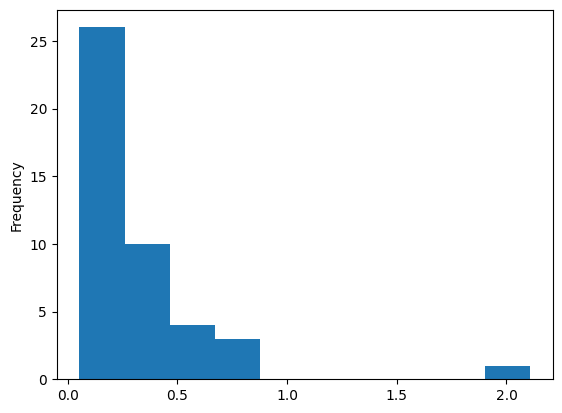

In [12]:
res.plot.hist()

In [13]:
list(res[res.values > 2].index)

['cHCC1599']

In [14]:
mat.drop(list(res[res.values > 2].index), axis=0, inplace=True)

In [15]:
X = mat.values
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
Xt = pca.fit_transform(X)

In [16]:
Xt.shape

(43, 10)

In [17]:
X.shape

(43, 52)

In [18]:
Xt[:, 0]

array([-8.71165161e-02, -5.54994925e+00,  1.55054274e+00, -5.71431927e-01,
        1.04743701e+00, -9.49369105e-01, -3.87328140e-01,  7.20078850e-01,
        2.24659705e+00,  5.25008478e+00, -6.41629085e-01, -2.79846822e+00,
       -1.95072309e-01,  4.07370366e-01,  6.00783501e+00, -1.03990967e+00,
       -4.51523654e+00, -3.39559321e+00, -2.11470299e+00, -1.67734373e+00,
       -1.08111497e+00, -5.11496083e+00,  3.21358400e-01, -3.99339299e+00,
       -2.45442473e+00,  1.14705234e+00,  2.81874097e+00,  6.30222683e+00,
        2.21758466e+00, -1.63753079e+00, -2.11411461e+00,  2.50106175e+00,
        2.89551095e+00,  1.30360823e+00, -6.26137884e-01, -2.45460694e-01,
        1.78828748e-01,  7.91014673e-04,  7.20879866e-01, -2.82459643e-01,
        1.52441178e+00,  2.31114458e+00, -3.98101559e-04])

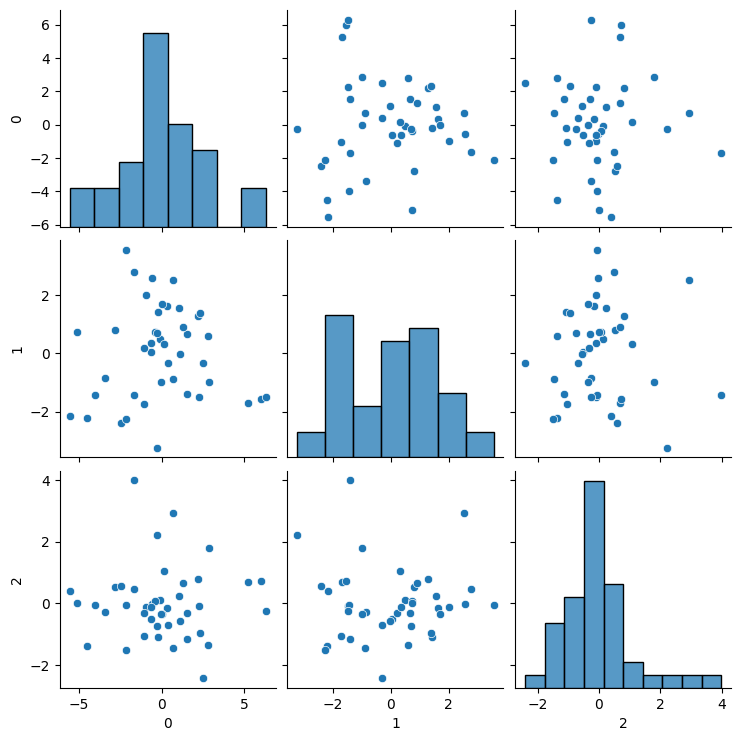

In [19]:
N_COMPS = 3
import seaborn as sns

sns.pairplot(pd.DataFrame(Xt[:, :3]))

In [20]:
pca.explained_variance_ratio_

array([0.4761864 , 0.17908113, 0.09506336, 0.06866907, 0.03626471,
       0.03035576, 0.01944038, 0.01477271, 0.01075752, 0.0101536 ])

In [21]:
pca.components_.shape

(10, 52)

In [22]:
pc_mat = pd.DataFrame(
    index=[f"PC{i}" for i in np.arange(N_COMPS)],
    data=pca.components_[:N_COMPS, :],
    columns=mat.columns,
)
pc_mat

measurement                                                     
observableId pERK_Y204_obs                                                     
perturbation           EGF                                                     
time                  0.0       5.5       7.0       9.0       17.0      23.0   
PC0              -0.155419 -0.172849 -0.182292 -0.191807 -0.217605 -0.191656  \
PC1              -0.058661  0.066771  0.077477  0.090472  0.075673  0.054330   
PC2               0.106106 -0.140377 -0.189301 -0.150532  0.019050  0.025553   

                                                      ...                 
observableId                                          ... pMEK_S222_obs   
perturbation                         iEGFR            ...          iMEK   
time              30.0      60.0      0.0       7.0   ...          60.0   
PC0          -0.213143 -0.189748 -0.133316 -0.209197  ...     -0.099429  \
PC1           0.042426  0.031904  0.069912  0.184907  ...     -0.153048   
PC2           0.015831  0.116585  0.297397 -0.108388  ...     -0.078577   

                                                                           
observableId                                                               
perturbation     iPI3K                          iPKC                       
time              0.0       9.0       60.0      0.0       7.0       9.0    
PC0          -0.039807 -0.074655 -0.079122 -0.033450 -0.080210 -0.087729  \
PC1          -0.189131 -0.197723 -0.217079 -0.199824 -0.147376 -0.160838   
PC2           0.025556 -0.014256  0.038574  0.017235 -0.032066 -0.045686   

                                            
observableId                                
perturbation                                
time              17.0      40.0      60.0  
PC0          -0.085785 -0.089785 -0.101179  
PC1          -0.146424 -0.176266 -0.193461  
PC2           0.013654 -0.020509  0.003267  

[3 rows x 52 columns]

In [23]:
pc_mat_long = pd.melt(pc_mat.reset_index(), id_vars="index")
pc_mat_long

,index,None,observableId,perturbation,time,value
0,PC0,measurement,pERK_Y204_obs,EGF,0.0,-0.155419
1,PC1,measurement,pERK_Y204_obs,EGF,0.0,-0.058661
2,PC2,measurement,pERK_Y204_obs,EGF,0.0,0.106106
3,PC0,measurement,pERK_Y204_obs,EGF,5.5,-0.172849
4,PC1,measurement,pERK_Y204_obs,EGF,5.5,0.066771
...,...,...,...,...,...,...
151,PC1,measurement,pMEK_S222_obs,iPKC,40.0,-0.176266
152,PC2,measurement,pMEK_S222_obs,iPKC,40.0,-0.020509
153,PC0,measurement,pMEK_S222_obs,iPKC,60.0,-0.101179
154,PC1,measurement,pMEK_S222_obs,iPKC,60.0,-0.193461


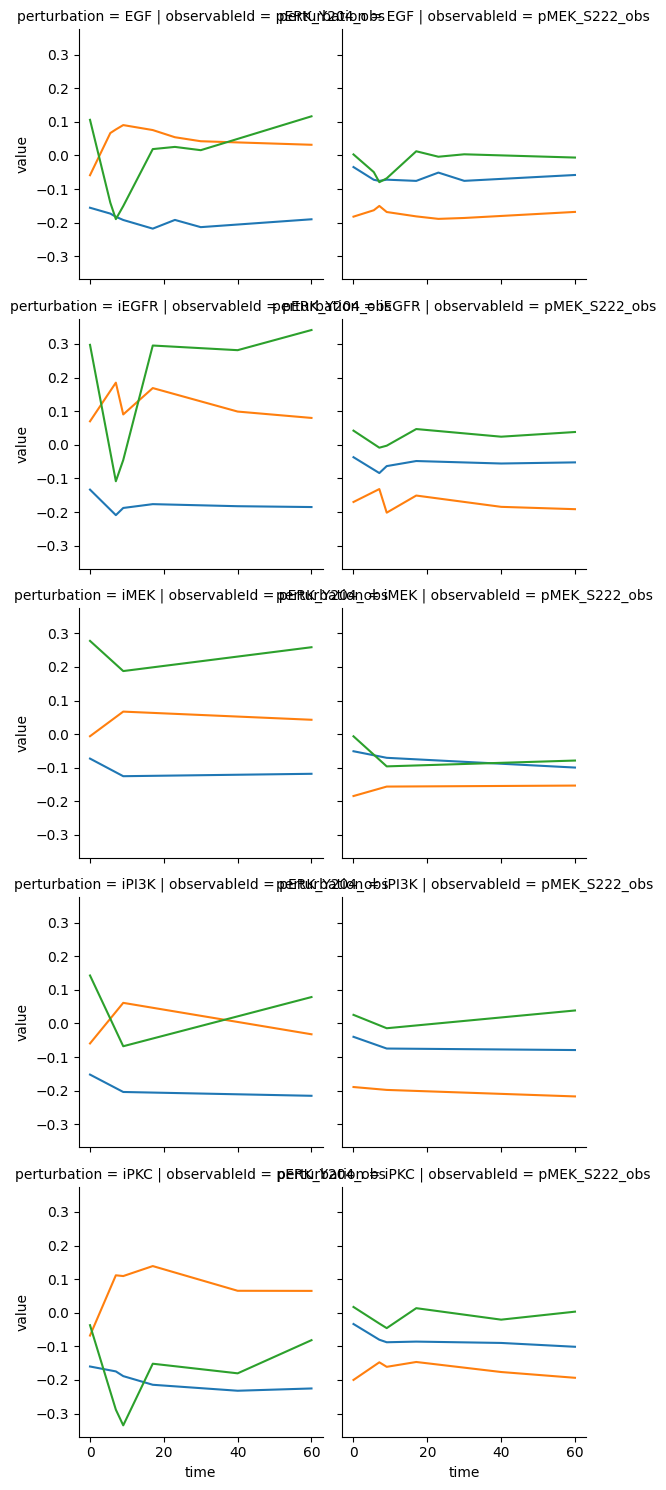

In [24]:
import seaborn as sns

g = sns.FacetGrid(
    data=pc_mat_long, col=petab.OBSERVABLE_ID, row="perturbation", hue="index"
)
g.map_dataframe(sns.lineplot, x="time", y="value")